In [ ]:
import pandas as pd
import numpy as np

file_path = "100_Pre_done_Combined.xlsx"

df = pd.read_excel(file_path)

print(df.columns)

df['Pstng Date'] = pd.to_datetime(df['Pstng Date'])


df = df.sort_values(
    by=['Equipment', 'Material', 'Pstng Date']
)

df['Next_Failure_Date'] = df.groupby(
    ['Equipment', 'Material']
)['Pstng Date'].shift(-1)

df['ON_Time_Days'] = (
    df['Next_Failure_Date'] - df['Pstng Date']
).dt.days

df['ON_Time_Days'] = df['ON_Time_Days'].apply(
    lambda x: 1 if pd.notna(x) and x <= 0 else x
)

df['ON_Time_Months'] = (
    df['ON_Time_Days'] / 30
)
processed_df = df.dropna(
    subset=['ON_Time_Days']
)
processed_df['Failure_Interval_No'] = processed_df.groupby(
    ['Equipment', 'Material']
).cumcount() + 1
def mtbf_category(days):

    if days < 30:
        return 'Very Low MTBF'

    elif days < 90:
        return 'Low MTBF'

    elif days < 180:
        return 'Medium MTBF'

    else:
        return 'High MTBF'

processed_df['MTBF_Category'] = processed_df[
    'ON_Time_Days'
].apply(mtbf_category)

def temperature_band(temp):

    if pd.isna(temp):
        return 'Unknown'

    elif temp < 15:
        return 'Cold'

    elif temp < 30:
        return 'Moderate'

    else:
        return 'Hot'

processed_df['Temperature_Band'] = processed_df[
    'Tavg'
].apply(temperature_band)

final_df = processed_df[
    [
        'Material',
        'Equipment',
        'SLoc',
        'Location',
        'Region',
        'Season',
        'Month',
        'Year',
        'Pstng Date',
        'Next_Failure_Date',
        'ON_Time_Days',
        'ON_Time_Months',
        'Tavg',
        'Tmax',
        'Tmin',
        'RH',
        'Delta_T',
        'Failure_Interval_No',
        'MTBF_Category',
        'Temperature_Band'
    ]
]

equipment_mtbf = final_df.groupby(
    ['Equipment', 'Material']
)['ON_Time_Days'].mean().reset_index()

equipment_mtbf.rename(
    columns={'ON_Time_Days': 'MTBF_Days'},
    inplace=True
)

final_df = pd.merge(
    final_df,
    equipment_mtbf,
    on=['Equipment', 'Material'],
    how='left'
)
final_df = final_df[
    [
        'Material',
        'Equipment',
        'SLoc',
        'Location',
        'Region',
        'Season',
        'Month',
        'Year',
        'Pstng Date',
        'Next_Failure_Date',
        'ON_Time_Days',
        'ON_Time_Months',
        'MTBF_Days',
        'Tavg',
        'Tmax',
        'Tmin',
        'RH',
        'Delta_T',
        'Failure_Interval_No',
        'MTBF_Category',
        'Temperature_Band'
    ]
]

print("\nProcessed MTBF Dataset:\n")

print(final_df.head(20))

output_file = "PCB_MTBF_Processed.xlsx"

final_df.to_excel(output_file, index=False)

print(f"\nFile saved as: {output_file}")

Index(['Material', 'SLoc', 'Quantity', 'Pstng Date', 'order', 'Equipment',
       'Technician name', 'Year', 'Tavg', 'Tmax', 'Tmin', 'RH', 'Month',
       'Season', 'Delta_T', 'Region', 'Location'],
      dtype='str')

Processed MTBF Dataset:

    Material Equipment  SLoc       Location  Region        Season  Month  \
0        100  10514645  5041      Bangalore   South        Summer      4   
1        100  10514665  5022  Uttar Pradesh  North1  Post-Monsoon     10   
2        100  10515280  5001         Mumbai   West1        Winter      1   
3        100  10515280  5001         Mumbai   West1        Winter      1   
4        100  10516155  5001         Mumbai   West1        Winter      2   
5        100  10516155  5001         Mumbai   West1        Summer      4   
6        100  10516155  5001         Mumbai   West1  Post-Monsoon     11   
7        100  10516545  5030          Delhi  North1        Summer      4   
8        100  10516545  5030          Delhi  North1        Summer      4

   Material Equipment  SLoc       Location  Region        Season  Month  Year  \
0       100  10514645  5041      Bangalore   South        Summer      4  2023   
1       100  10514665  5022  Uttar Pradesh  North1  Post-Monsoon     10  2023   
2       100  10515280  5001         Mumbai   West1        Winter      1  2020   
3       100  10515280  5001         Mumbai   West1        Winter      1  2023   
4       100  10516155  5001         Mumbai   West1        Winter      2  2020   

  Pstng Date Next_Failure_Date  ...  ON_Time_Months  MTBF_Days   Tavg   Tmax  \
0 2023-04-14        2023-06-12  ...        1.966667       59.0  28.34  36.05   
1 2023-10-19        2023-12-27  ...        2.300000       69.0  23.98  30.67   
2 2020-01-23        2023-01-27  ...       36.666667     1017.0  24.22  32.58   
3 2023-01-27        2025-08-18  ...       31.133333     1017.0  25.15  34.14   
4 2020-02-13        2023-04-26  ...       38.933333      551.0  26.44  34.54   

    Tmin     RH  Delta_T  Failur

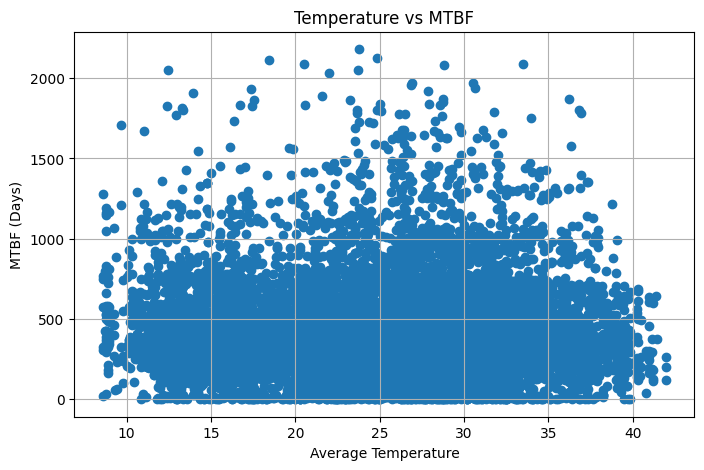

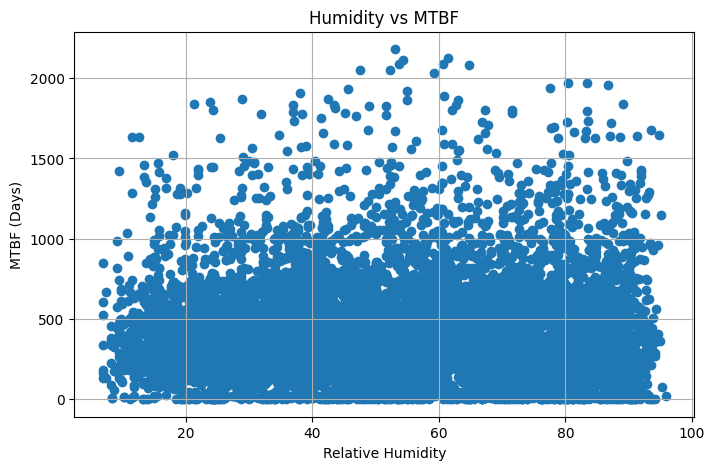

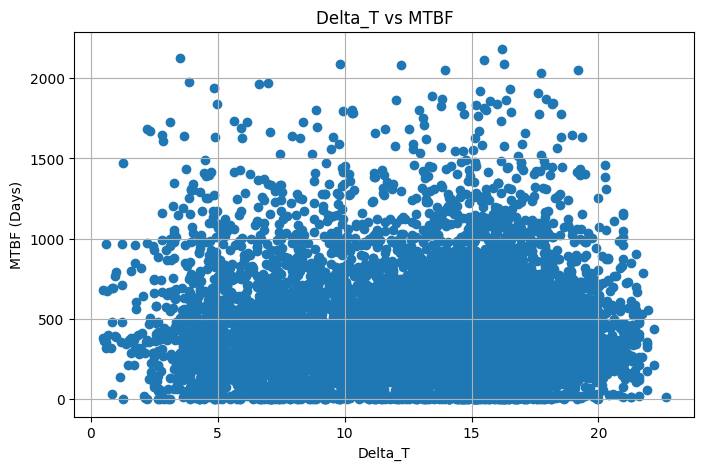

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


file_path = "PCB_MTBF_Processed.xlsx"

df = pd.read_excel(file_path)


print(df.head())
monthly_region_mtbf = df.groupby(
    ['Region', 'Month']
)['MTBF_Days'].mean().reset_index()

monthly_region_mtbf.rename(
    columns={'MTBF_Days': 'Avg_MTBF_Days'},
    inplace=True
)

print("\nMonthly Regional MTBF:\n")
print(monthly_region_mtbf.head())

seasonal_region_mtbf = df.groupby(
    ['Region', 'Season']
)['MTBF_Days'].mean().reset_index()

seasonal_region_mtbf.rename(
    columns={'MTBF_Days': 'Avg_MTBF_Days'},
    inplace=True
)

print("\nSeasonal Regional MTBF:\n")
print(seasonal_region_mtbf.head())

temp_vs_mtbf = df[
    ['Tavg', 'MTBF_Days']
].dropna()

print("\nTemperature vs MTBF:\n")
print(temp_vs_mtbf.head())

humidity_vs_mtbf = df[
    ['RH', 'MTBF_Days']
].dropna()

print("\nHumidity vs MTBF:\n")
print(humidity_vs_mtbf.head())

deltaT_vs_mtbf = df[
    ['Delta_T', 'MTBF_Days']
].dropna()

print("\nDelta_T vs MTBF:\n")
print(deltaT_vs_mtbf.head())

region_mtbf = df.groupby(
    ['Region']
)['MTBF_Days'].mean().reset_index()

region_mtbf.rename(
    columns={'MTBF_Days': 'Region_MTBF_Days'},
    inplace=True
)

season_mtbf = df.groupby(
    ['Season']
)['MTBF_Days'].mean().reset_index()

season_mtbf.rename(
    columns={'MTBF_Days': 'Season_MTBF_Days'},
    inplace=True
)

output_file = "MTBF_Analysis_Output.xlsx"

with pd.ExcelWriter(output_file) as writer:

    monthly_region_mtbf.to_excel(
        writer,
        sheet_name='Monthly_Regional_MTBF',
        index=False
    )

    seasonal_region_mtbf.to_excel(
        writer,
        sheet_name='Seasonal_Regional_MTBF',
        index=False
    )

    temp_vs_mtbf.to_excel(
        writer,
        sheet_name='Temp_vs_MTBF',
        index=False
    )

    humidity_vs_mtbf.to_excel(
        writer,
        sheet_name='Humidity_vs_MTBF',
        index=False
    )

    deltaT_vs_mtbf.to_excel(
        writer,
        sheet_name='DeltaT_vs_MTBF',
        index=False
    )

    region_mtbf.to_excel(
        writer,
        sheet_name='Region_MTBF',
        index=False
    )

    season_mtbf.to_excel(
        writer,
        sheet_name='Season_MTBF',
        index=False
    )

print(f"\nAnalysis file saved as: {output_file}")

plt.figure(figsize=(8,5))

plt.scatter(
    df['Tavg'],
    df['MTBF_Days']
)

plt.xlabel("Average Temperature")
plt.ylabel("MTBF (Days)")
plt.title("Temperature vs MTBF")

plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    df['RH'],
    df['MTBF_Days']
)

plt.xlabel("Relative Humidity")
plt.ylabel("MTBF (Days)")
plt.title("Humidity vs MTBF")

plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    df['Delta_T'],
    df['MTBF_Days']
)

plt.xlabel("Delta_T")
plt.ylabel("MTBF (Days)")
plt.title("Delta_T vs MTBF")

plt.grid(True)

plt.show()

In [3]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# LOAD MTBF DATASET
# ============================================================

file_path = "PCB_MTBF_Processed.xlsx"

df = pd.read_excel(file_path)

# ============================================================
# DISPLAY SAMPLE DATA
# ============================================================

print(df.head())

# ============================================================
# 1. MONTHLY REGIONAL MTBF
# ============================================================

monthly_region_mtbf = df.groupby(
    ['Region', 'Month']
).agg({
    'MTBF_Days': 'mean',
    'Tavg': 'mean',
    'RH': 'mean',
    'Delta_T': 'mean'
}).reset_index()

monthly_region_mtbf.rename(
    columns={
        'MTBF_Days': 'Avg_MTBF_Days',
        'Tavg': 'Avg_Temperature',
        'RH': 'Avg_Humidity',
        'Delta_T': 'Avg_Delta_T'
    },
    inplace=True
)

print("\nMonthly Regional MTBF:\n")
print(monthly_region_mtbf.head())

# ============================================================
# 2. SEASONAL REGIONAL MTBF
# ============================================================

seasonal_region_mtbf = df.groupby(
    ['Region', 'Season']
).agg({
    'MTBF_Days': 'mean',
    'Tavg': 'mean',
    'RH': 'mean',
    'Delta_T': 'mean'
}).reset_index()

seasonal_region_mtbf.rename(
    columns={
        'MTBF_Days': 'Avg_MTBF_Days',
        'Tavg': 'Avg_Temperature',
        'RH': 'Avg_Humidity',
        'Delta_T': 'Avg_Delta_T'
    },
    inplace=True
)

print("\nSeasonal Regional MTBF:\n")
print(seasonal_region_mtbf.head())

# ============================================================
# 3. MONTHLY SLOC MTBF
# ============================================================

monthly_sloc_mtbf = df.groupby(
    ['SLoc', 'Month']
).agg({
    'MTBF_Days': 'mean',
    'Tavg': 'mean',
    'RH': 'mean',
    'Delta_T': 'mean'
}).reset_index()

monthly_sloc_mtbf.rename(
    columns={
        'MTBF_Days': 'Avg_MTBF_Days',
        'Tavg': 'Avg_Temperature',
        'RH': 'Avg_Humidity',
        'Delta_T': 'Avg_Delta_T'
    },
    inplace=True
)

print("\nMonthly SLoc MTBF:\n")
print(monthly_sloc_mtbf.head())

# ============================================================
# 4. SEASONAL SLOC MTBF
# ============================================================

seasonal_sloc_mtbf = df.groupby(
    ['SLoc', 'Season']
).agg({
    'MTBF_Days': 'mean',
    'Tavg': 'mean',
    'RH': 'mean',
    'Delta_T': 'mean'
}).reset_index()

seasonal_sloc_mtbf.rename(
    columns={
        'MTBF_Days': 'Avg_MTBF_Days',
        'Tavg': 'Avg_Temperature',
        'RH': 'Avg_Humidity',
        'Delta_T': 'Avg_Delta_T'
    },
    inplace=True
)

print("\nSeasonal SLoc MTBF:\n")
print(seasonal_sloc_mtbf.head())

# ============================================================
# SAVE OUTPUT FILE
# ============================================================

output_file = "MTBF_Monthly_Seasonal_Analysis.xlsx"

with pd.ExcelWriter(output_file) as writer:

    monthly_region_mtbf.to_excel(
        writer,
        sheet_name='Monthly_Region_MTBF',
        index=False
    )

    seasonal_region_mtbf.to_excel(
        writer,
        sheet_name='Seasonal_Region_MTBF',
        index=False
    )

    monthly_sloc_mtbf.to_excel(
        writer,
        sheet_name='Monthly_SLoc_MTBF',
        index=False
    )

    seasonal_sloc_mtbf.to_excel(
        writer,
        sheet_name='Seasonal_SLoc_MTBF',
        index=False
    )

print(f"\nAnalysis saved as: {output_file}")

   Material Equipment  SLoc       Location  Region        Season  Month  Year  \
0       100  10514645  5041      Bangalore   South        Summer      4  2023   
1       100  10514665  5022  Uttar Pradesh  North1  Post-Monsoon     10  2023   
2       100  10515280  5001         Mumbai   West1        Winter      1  2020   
3       100  10515280  5001         Mumbai   West1        Winter      1  2023   
4       100  10516155  5001         Mumbai   West1        Winter      2  2020   

  Pstng Date Next_Failure_Date  ...  ON_Time_Months  MTBF_Days   Tavg   Tmax  \
0 2023-04-14        2023-06-12  ...        1.966667       59.0  28.34  36.05   
1 2023-10-19        2023-12-27  ...        2.300000       69.0  23.98  30.67   
2 2020-01-23        2023-01-27  ...       36.666667     1017.0  24.22  32.58   
3 2023-01-27        2025-08-18  ...       31.133333     1017.0  25.15  34.14   
4 2020-02-13        2023-04-26  ...       38.933333      551.0  26.44  34.54   

    Tmin     RH  Delta_T  Failur

In [ ]:
import pandas as pd
import numpy as np

from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import f_oneway
from scipy.stats import kruskal

file_path = "PCB_MTBF_Processed.xlsx"

df = pd.read_excel(file_path)

df = df.dropna(
    subset=[
        'MTBF_Days',
        'Tavg',
        'RH',
        'Delta_T',
        'Region',
        'Season',
        'SLoc'
    ]
)

results = []

pearson_temp = pearsonr(
    df['Tavg'],
    df['MTBF_Days']
)

results.append({
    'Test': 'Pearson',
    'Parameter': 'Temperature vs MTBF',
    'Statistic': pearson_temp.statistic,
    'P_Value': pearson_temp.pvalue
})

pearson_rh = pearsonr(
    df['RH'],
    df['MTBF_Days']
)

results.append({
    'Test': 'Pearson',
    'Parameter': 'Humidity vs MTBF',
    'Statistic': pearson_rh.statistic,
    'P_Value': pearson_rh.pvalue
})

pearson_delta = pearsonr(
    df['Delta_T'],
    df['MTBF_Days']
)

results.append({
    'Test': 'Pearson',
    'Parameter': 'Delta_T vs MTBF',
    'Statistic': pearson_delta.statistic,
    'P_Value': pearson_delta.pvalue
})
spearman_temp = spearmanr(
    df['Tavg'],
    df['MTBF_Days']
)

results.append({
    'Test': 'Spearman',
    'Parameter': 'Temperature vs MTBF',
    'Statistic': spearman_temp.statistic,
    'P_Value': spearman_temp.pvalue
})


spearman_rh = spearmanr(
    df['RH'],
    df['MTBF_Days']
)

results.append({
    'Test': 'Spearman',
    'Parameter': 'Humidity vs MTBF',
    'Statistic': spearman_rh.statistic,
    'P_Value': spearman_rh.pvalue
})


spearman_delta = spearmanr(
    df['Delta_T'],
    df['MTBF_Days']
)

results.append({
    'Test': 'Spearman',
    'Parameter': 'Delta_T vs MTBF',
    'Statistic': spearman_delta.statistic,
    'P_Value': spearman_delta.pvalue
})

region_groups = [
    group['MTBF_Days'].values
    for name, group in df.groupby('Region')
]

anova_region = f_oneway(*region_groups)

results.append({
    'Test': 'ANOVA',
    'Parameter': 'Region-wise MTBF',
    'Statistic': anova_region.statistic,
    'P_Value': anova_region.pvalue
})

season_groups = [
    group['MTBF_Days'].values
    for name, group in df.groupby('Season')
]

anova_season = f_oneway(*season_groups)

results.append({
    'Test': 'ANOVA',
    'Parameter': 'Season-wise MTBF',
    'Statistic': anova_season.statistic,
    'P_Value': anova_season.pvalue
})

sloc_groups = [
    group['MTBF_Days'].values
    for name, group in df.groupby('SLoc')
]

anova_sloc = f_oneway(*sloc_groups)

results.append({
    'Test': 'ANOVA',
    'Parameter': 'SLoc-wise MTBF',
    'Statistic': anova_sloc.statistic,
    'P_Value': anova_sloc.pvalue
})


kruskal_region = kruskal(*region_groups)

results.append({
    'Test': 'Kruskal',
    'Parameter': 'Region-wise MTBF',
    'Statistic': kruskal_region.statistic,
    'P_Value': kruskal_region.pvalue
})

kruskal_season = kruskal(*season_groups)

results.append({
    'Test': 'Kruskal',
    'Parameter': 'Season-wise MTBF',
    'Statistic': kruskal_season.statistic,
    'P_Value': kruskal_season.pvalue
})

kruskal_sloc = kruskal(*sloc_groups)

results.append({
    'Test': 'Kruskal',
    'Parameter': 'SLoc-wise MTBF',
    'Statistic': kruskal_sloc.statistic,
    'P_Value': kruskal_sloc.pvalue
})

results_df = pd.DataFrame(results)

results_df['Interpretation'] = results_df[
    'P_Value'
].apply(
    lambda x:
    'Significant Relation'
    if x < 0.05
    else 'No Significant Relation'
)

print("\nStatistical Analysis Results:\n")

print(results_df)

output_file = "MTBF_Statistical_Analysis.xlsx"

results_df.to_excel(
    output_file,
    index=False
)

print(f"\nStatistical analysis saved as: {output_file}")


Statistical Analysis Results:

        Test            Parameter    Statistic        P_Value  \
0    Pearson  Temperature vs MTBF    -0.022456   2.617335e-02   
1    Pearson     Humidity vs MTBF     0.034366   6.653395e-04   
2    Pearson      Delta_T vs MTBF    -0.015612   1.221598e-01   
3   Spearman  Temperature vs MTBF    -0.029298   3.715738e-03   
4   Spearman     Humidity vs MTBF     0.007477   4.591284e-01   
5   Spearman      Delta_T vs MTBF     0.014387   1.542985e-01   
6      ANOVA     Region-wise MTBF    14.353569   4.951640e-14   
7      ANOVA     Season-wise MTBF     2.847366   3.609468e-02   
8      ANOVA       SLoc-wise MTBF    21.830155  2.489879e-238   
9    Kruskal     Region-wise MTBF    70.984774   6.392057e-14   
10   Kruskal     Season-wise MTBF    16.683927   8.207948e-04   
11   Kruskal       SLoc-wise MTBF  1103.669102  4.840663e-188   

             Interpretation  
0      Significant Relation  
1      Significant Relation  
2   No Significant Relation  
3 

In [5]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
from scipy.stats import kendalltau

# ============================================================
# LOAD DATASET
# ============================================================

file_path = "PCB_MTBF_Processed.xlsx"

df = pd.read_excel(file_path)

# ============================================================
# REMOVE NULL VALUES
# ============================================================

temp_mtbf_df = df[
    ['Tavg', 'MTBF_Days']
].dropna()

# ============================================================
# KENDALL TAU CORRELATION
# ============================================================

kendall_result = kendalltau(
    temp_mtbf_df['Tavg'],
    temp_mtbf_df['MTBF_Days']
)

# ============================================================
# EXTRACT RESULTS
# ============================================================

tau_value = kendall_result.statistic
p_value = kendall_result.pvalue

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\nKendall Tau Correlation: Temperature vs MTBF\n")

print(f"Kendall Tau Value : {tau_value}")

print(f"P-Value           : {p_value}")

# ============================================================
# INTERPRETATION
# ============================================================

if p_value < 0.05:
    print("\nResult: Significant Relationship Exists")

else:
    print("\nResult: No Significant Relationship")

# ============================================================
# RELATION DIRECTION
# ============================================================

if tau_value > 0:
    print("Direction: Positive Correlation")

elif tau_value < 0:
    print("Direction: Negative Correlation")

else:
    print("Direction: No Correlation")


Kendall Tau Correlation: Temperature vs MTBF

Kendall Tau Value : -0.019439963491500158
P-Value           : 0.0039146671398541605

Result: Significant Relationship Exists
Direction: Negative Correlation
